<a href="https://colab.research.google.com/github/jesmithamylavarapu-code/neuro_ps1/blob/main/basiceegdataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install mne
#python package

In [ ]:
import mne
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
!wget -O S001R03.edf https://physionet.org/files/eegmmidb/1.0.0/S001/S001R03.edf
#downloads an EEG data file from the internet to google colab


--2026-09-09 05:41:28--  https://physionet.org/files/eegmmidb/1.0.0/S001/S001R03.edf
Resolving physionet.org (physionet.org)... 18.25.8.254
Connecting to physionet.org (physionet.org)|18.25.8.254|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2596896 (2.5M) [application/octet-stream]
Saving to: ‘S001R03.edf’

S001R03.edf         100%[===================>]   2.48M   200KB/s    in 13s     

2026-09-09 05:41:42 (197 KB/s) - ‘S001R03.edf’ saved [2596896/2596896]



In [ ]:
raw = mne.io.read_raw_edf(
    "S001R03.edf",
    preload=True
)

print(raw)
# read the raw eeg dataset and load the dataset and print the data set

Extracting EDF parameters from S001R03.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
<RawEDF | S001R03.edf, 64 x 20000 (125.0 s), ~9.8 MiB, data loaded>


In [ ]:
print("Number of channels:", len(raw.ch_names))
print("Sampling frequency:", raw.info["sfreq"])
print("Channel names:")
print(raw.ch_names)
#prints number of channels,how many samples per sec were recording,list of all channels names

Number of channels: 64
Sampling frequency: 160.0
Channel names:
['Fc5.', 'Fc3.', 'Fc1.', 'Fcz.', 'Fc2.', 'Fc4.', 'Fc6.', 'C5..', 'C3..', 'C1..', 'Cz..', 'C2..', 'C4..', 'C6..', 'Cp5.', 'Cp3.', 'Cp1.', 'Cpz.', 'Cp2.', 'Cp4.', 'Cp6.', 'Fp1.', 'Fpz.', 'Fp2.', 'Af7.', 'Af3.', 'Afz.', 'Af4.', 'Af8.', 'F7..', 'F5..', 'F3..', 'F1..', 'Fz..', 'F2..', 'F4..', 'F6..', 'F8..', 'Ft7.', 'Ft8.', 'T7..', 'T8..', 'T9..', 'T10.', 'Tp7.', 'Tp8.', 'P7..', 'P5..', 'P3..', 'P1..', 'Pz..', 'P2..', 'P4..', 'P6..', 'P8..', 'Po7.', 'Po3.', 'Poz.', 'Po4.', 'Po8.', 'O1..', 'Oz..', 'O2..', 'Iz..']


Using matplotlib as 2D backend.


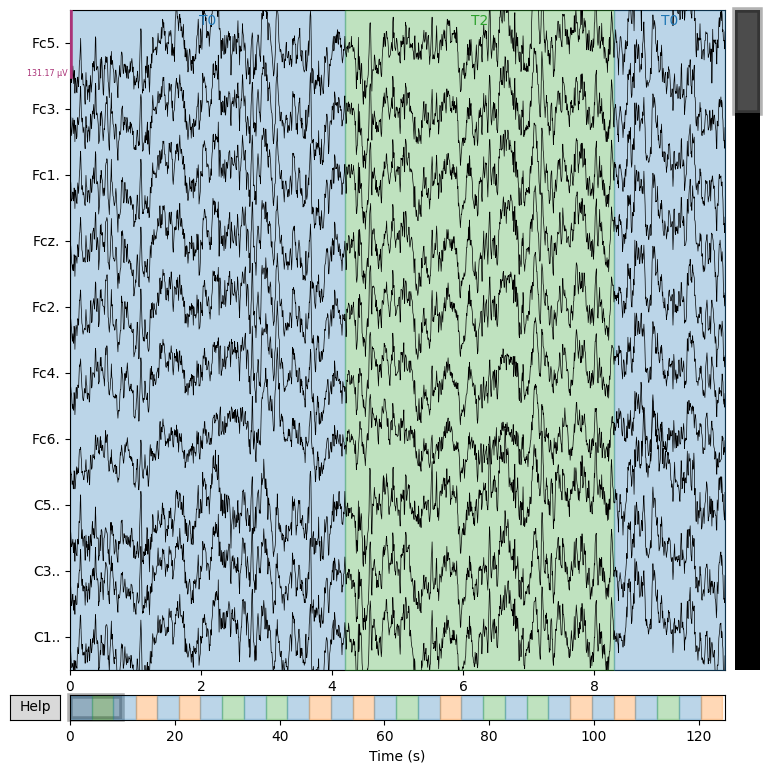

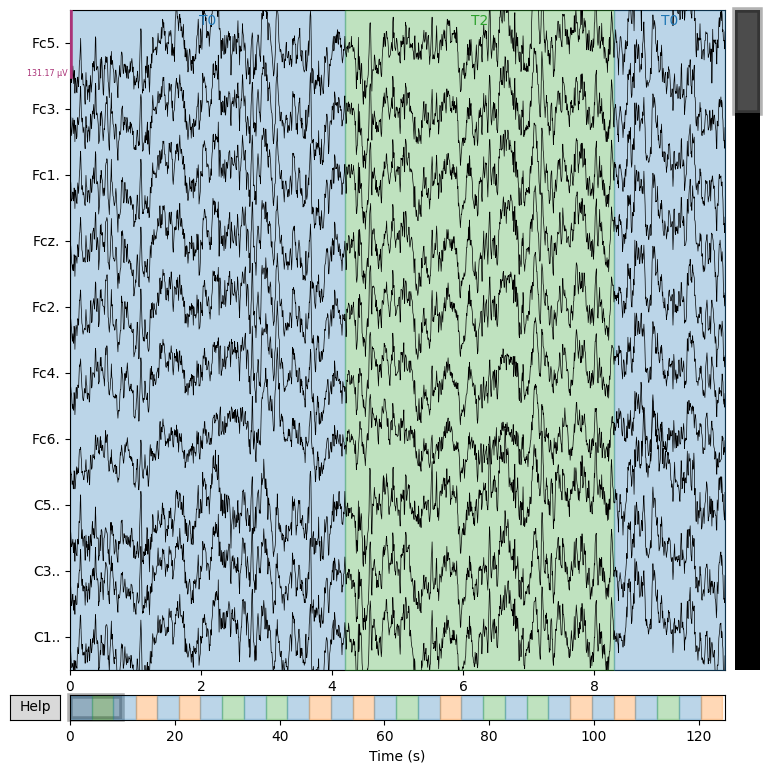

In [ ]:
raw.plot(
    duration=10,
    n_channels=10,
    scalings="auto"
)

In [ ]:
raw.pick("eeg")

print("EEG channels:", len(raw.ch_names))

EEG channels: 64


In [ ]:
raw.filter(
    l_freq=1,
    h_freq=40
)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 529 samples (3.306 s)



<RawEDF | S001R03.edf, 64 x 20000 (125.0 s), ~9.8 MiB, data loaded>

In [ ]:
raw.notch_filter(freqs=50)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband edge: 50.62 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 50.88 Hz)
- Filter length: 1057 samples (6.606 s)



<RawEDF | S001R03.edf, 64 x 20000 (125.0 s), ~9.8 MiB, data loaded>

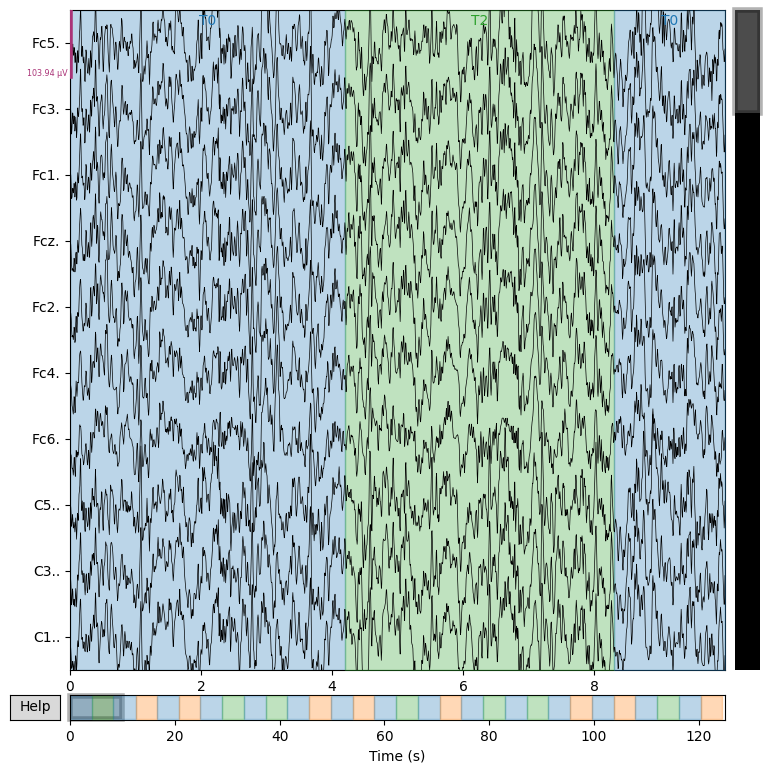

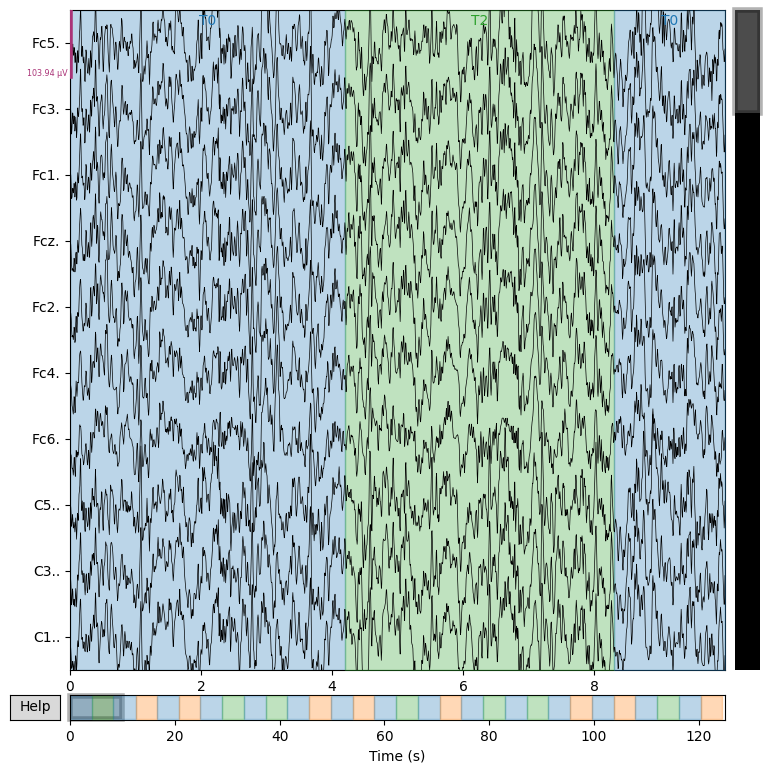

In [ ]:
raw.plot(
    duration=10,
    n_channels=10,
    scalings="auto"
)

In [ ]:
raw.set_eeg_reference("average")

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.


<RawEDF | S001R03.edf, 64 x 20000 (125.0 s), ~9.8 MiB, data loaded>

In [ ]:
data = raw.get_data()

print("Shape:", data.shape)
print("NaN values:", np.isnan(data).sum())
print("Infinite values:", np.isinf(data).sum())

Shape: (64, 20000)
NaN values: 0
Infinite values: 0


In [ ]:
from sklearn.preprocessing import StandardScaler

data = raw.get_data()

scaler = StandardScaler()

data_normalized = scaler.fit_transform(data.T).T

print("Normalized shape:", data_normalized.shape)

Normalized shape: (64, 20000)


In [ ]:
events, event_dict = mne.events_from_annotations(raw)

print("Events:")
print(events[:10])

print("\nEvent dictionary:")
print(event_dict)

Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Events:
[[   0    0    1]
 [ 672    0    3]
 [1328    0    1]
 [2000    0    2]
 [2656    0    1]
 [3328    0    2]
 [3984    0    1]
 [4656    0    3]
 [5312    0    1]
 [5984    0    3]]

Event dictionary:
{np.str_('T0'): 1, np.str_('T1'): 2, np.str_('T2'): 3}


In [ ]:
epochs = mne.Epochs(
    raw,
    events,
    event_id=event_dict,
    tmin=0,
    tmax=2,
    baseline=None,
    preload=True
)

print(epochs)

Not setting metadata
30 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 30 events and 321 original time points ...
0 bad epochs dropped
<Epochs | 30 events (all good), 0 – 2 s (baseline off), ~4.8 MiB, data loaded,
 np.str_('T0'): 15
 np.str_('T1'): 8
 np.str_('T2'): 7>


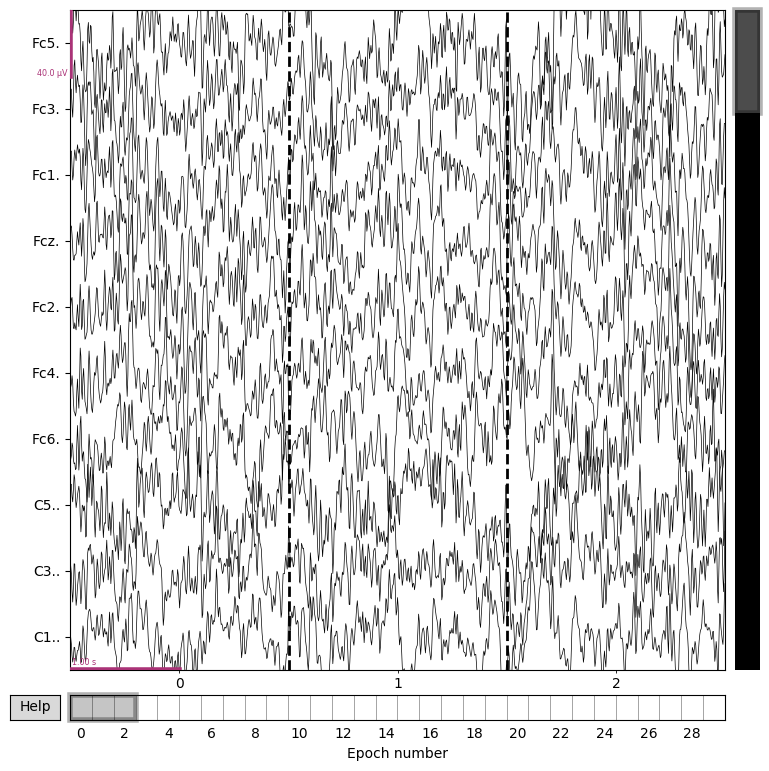

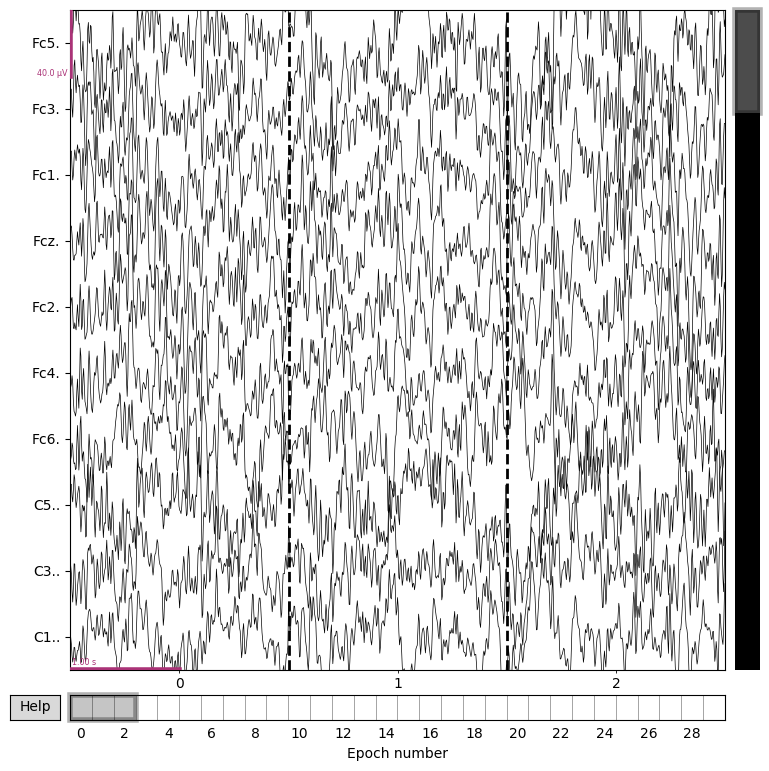

In [ ]:
epochs.plot(
    n_epochs=3,
    n_channels=10
)

In [ ]:
raw.save(
    "S001R03_preprocessed.fif",
    overwrite=True
)

Writing /content/S001R03_preprocessed.fif
Closing /content/S001R03_preprocessed.fif
[done]


/tmp/ipykernel_739/1624883988.py:1: RuntimeWarning: This filename (/content/S001R03_preprocessed.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw.save(


[PosixPath('/content/S001R03_preprocessed.fif')]